# Assignment 3

***


SetUp

In [271]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

import requests

'''
Data dictionary :  https://files.ontario.ca/fuelsdatadictionary_0.xlsx

'''

# Import dataset from csv file to a dataframe
df = pd.read_csv("https://ontario.ca/v1/files/fuel-prices/fueltypesall.csv")

# Changing data type for date for easier manipulation.
df['Date'] = pd.to_datetime(df['Date'])


''' 
Creation of subset for visualizations with specific columns:
 * Date
 * Ontario Average
 * Fuel Type
 * Data from 1990 - prev year.

'''

# Date filters.
# Excluding current year to show only complete years.
current_year = datetime.now().year
past_10_year = (datetime.now().year-1)-10


df_viz = df.iloc[:, [0,15,18]].copy()
df_viz = df_viz[df_viz['Date'].dt.year < current_year]

# Renaming of columns
df_viz = df_viz.rename(columns={"Ontario Average/Moyenne provinciale": "Ontario Price"})



***

## Visualization #1

In [272]:
''' 
For Visualization #1
Goal: Represent the average price of all types of fuels across time in Ontario.
 
'''

# Calculate Avg per year and per fuel type.
yearly_avg = df_viz.groupby([df_viz['Date'].dt.year, df_viz['Fuel Type']])['Ontario Price'].mean().reset_index()
yearly_avg

,Date,Fuel Type,Ontario Price
0,1990,Auto Propane,24.417308
1,1990,Compressed Natural Gas,33.315385
2,1990,Diesel,49.794231
3,1990,Mid-Grade Gasoline,58.826923
4,1990,Premium Gasoline,60.832692
...,...,...,...
210,2025,Compressed Natural Gas,90.400000
211,2025,Diesel,146.063462
212,2025,Mid-Grade Gasoline,159.038462
213,2025,Premium Gasoline,168.084615


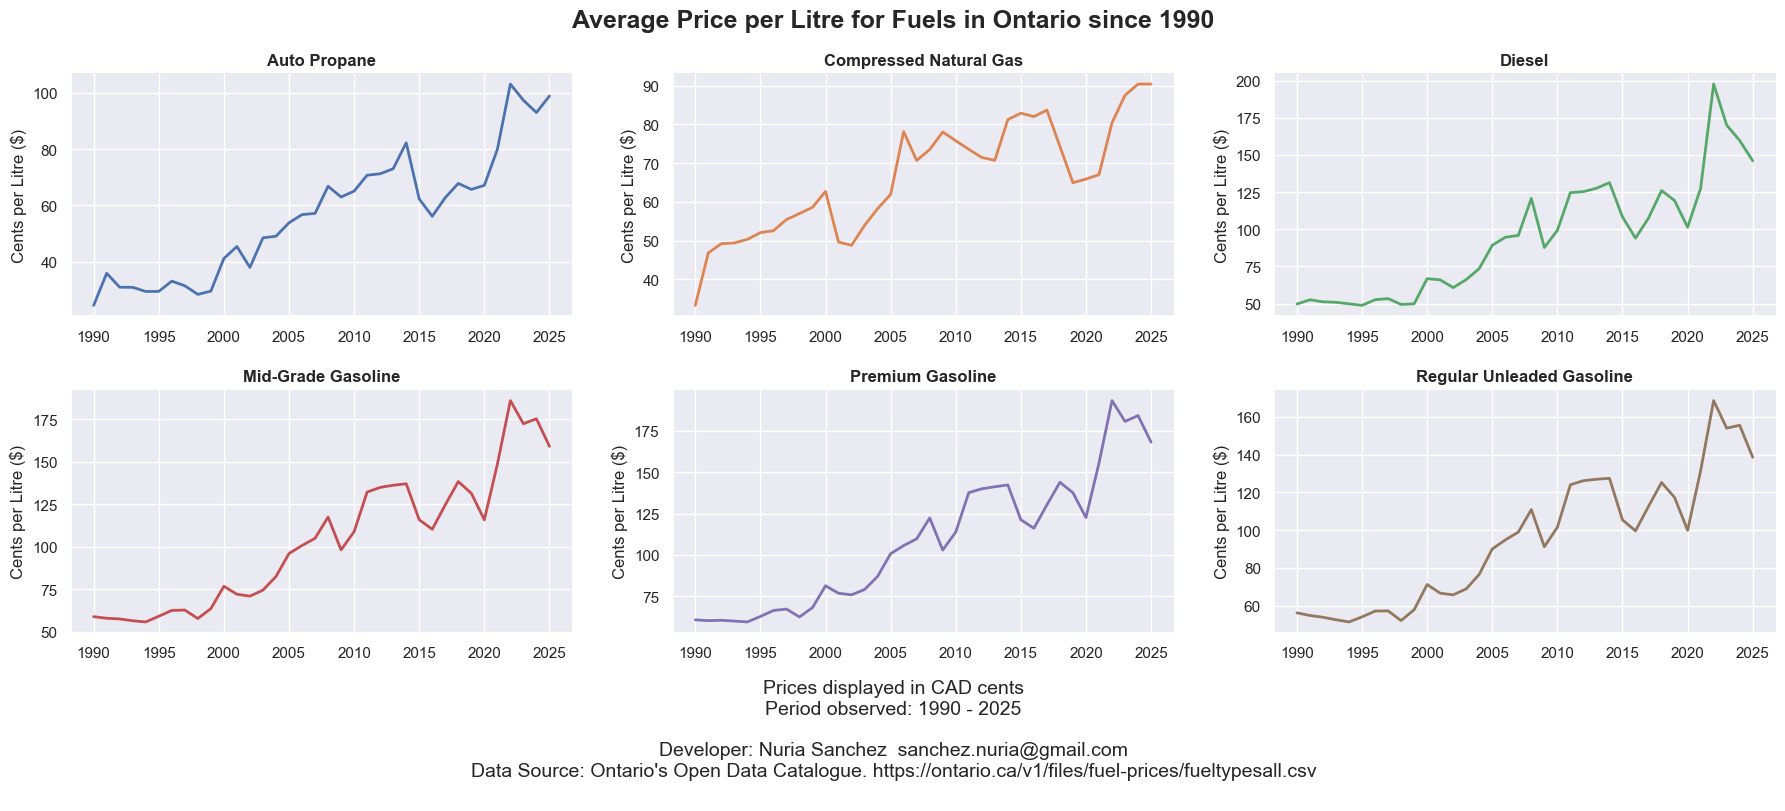

In [273]:
#Comparing specific levels to eachother.

sns.set_style("darkgrid")
fuelsplot = sns.relplot(
    data = yearly_avg,
    x='Date',
    y='Ontario Price',
    hue = 'Fuel Type', # Using the fuel type column for color.
    col = 'Fuel Type', # Creation of graphs per fuel type
    kind = 'line', # Type of graphs created
    col_wrap = 3, # Number of columns to show graphs.
    height= 4,
    aspect=1.5,
    linewidth=2 ,
    legend = False,
    facet_kws={'sharex': False, 'sharey': False}
    )


# Labels
fuelsplot.set_titles( template= "{col_name}",fontweight='bold', fontsize=20)
fuelsplot.set(ylabel = "Cents per Litre ($)",
              xlabel= None)

# Title
fuelsplot.fig.suptitle('Average Price per Litre for Fuels in Ontario since 1990', fontsize=18, fontweight='bold')
fuelsplot.fig.subplots_adjust(top=0.9)


#Annotation
note =  f"""
Prices displayed in CAD cents
Period observed: 1990 - {current_year-1}

Developer: Nuria Sanchez  sanchez.nuria@gmail.com
Data Source: Ontario's Open Data Catalogue. https://ontario.ca/v1/files/fuel-prices/fueltypesall.csv
"""

plt.figtext(0.5, -0.01, note, 
            ha="center", fontsize=14, va="bottom")

# Adjust layout to prevent clipping
plt.subplots_adjust(bottom=0.2) 
fuelsplot.fig.subplots_adjust(wspace=0.2, hspace=0.3)


plt.savefig('visualization1.png')
plt.show()




## Average Price per Litre for Fuels in Ontario, since 1990.

The visualization represents the average price for fuels in Ontario from 1990 to the most recently completed year. Prices are represented in cents per litre. The fuels considered are:
* Auto Propane
* Compressed Natural Gas
* Diesel
* Mid-Grade Gasoline
* Premiumn Gasoline
* Regular Unleaded Gasoline

---

I created my data visualization using Python, specifically leveraging the Seaborn library to generate a relplot line graph. I selected this library because its a great tool for creating attractive and informative graphics, and the relplot function was selected to properly display the different types of fuel across the date frame.

The intended audience includes policymakers, researchers, students, business professionals in the energy and transportation sectors, and residents of Ontario who are interested in understanding long-term fuel price trends. Because fuel prices directly affect household budgets, transportation planning, and economic policy, the visualization was designed to be accessible to both technical and non-technical audiences.

The primary message of the visualization is to show how fuel prices in Ontario have evolved over time, highlighting long-term trends, fluctuations, and potential periods of volatility. By presenting the data in a continuous line graph, viewers can easily observe patterns such as gradual increases, sharp spikes, or periods of relative stability. The goal is not only to present raw data, but to make historical price evolution immediately interpretable.

Several design principles guided the creation of the visualization. First, clarity and readability were central considerations. I used a font size of 20 for the main title, 18 for subtitles, and 14 for notes to create a clear visual hierarchy. This ensures that viewers can quickly identify the purpose of the graph and interpret contextual information without straining to read small text. I also forced axis labels to repeat on each graph panel to improve comprehension, especially if multiple facets are displayed. This prevents viewers from having to search for contextual clues elsewhere on the figure.

Color accessibility was another major design consideration. The visualization does not rely on color differences for interpretation, meaning that viewers with color vision deficiencies can interpret the graph without difficulty. Instead, understanding is driven by the line structure, axis labeling, and grid alignment. Additionally, the background contrast and visible gridlines were intentionally selected to help viewers accurately track values across the chart. The grid makes it easier to determine where the lines intersect with specific price levels and years, improving precision in interpretation.

Reproducibility was ensured by creating the visualization entirely in Python code. Because the plot is generated programmatically using Seaborn, anyone with access to the dataset and the script can recreate the exact same visualization. This enhances transparency and credibility. In addition, I incorporated dynamic time variables (such as automatically detecting the latest completed year in the dataset rather than hardcoding a fixed end date). This ensures that when new yearly data is added, the script updates the time range automatically without requiring manual changes to the code. Using code ensures that updates to the dataset can automatically regenerate an updated figure.

Accessibility was considered beyond color usage. Clear font sizing improves readability for individuals with mild visual impairments. The structured layout, consistent labeling, and high contrast between the grid and background support users who benefit from strong visual guidance. Furthermore, by avoiding excessive decorative elements, the visualization minimizes cognitive load and makes the information straightforward to interpret.

The individuals and communities impacted by this visualization include Ontario residents, particularly drivers and households affected by fuel price fluctuations. Policymakers and economists may use this information to analyze long-term cost trends, while businesses in logistics and transportation could use it for strategic planning. Researchers studying inflation, environmental policy, or energy economics may also find the visualization informative.

When selecting features from the dataset, I focused on variables directly relevant to the message: year and average fuel price in the province of Ontario. Additional variables that did not directly contribute to understanding long-term trends were excluded to maintain clarity and avoid visual clutter. The time range was intentionally set from 1990 to the latest completed year to provide sufficient historical context while keeping the focus on meaningful longitudinal change.

Finally, as “underwater labour” contributed to the final product, there were steps for cleaning and validating the dataset, ensuring consistent formatting across years, and confirming that averages were correctly calculated. Additional unseen work included iterating on design choices, adjusting axis formatting, refining grid visibility, testing font scaling for readability, and verifying that the visualization rendered consistently across different screen sizes. Although not immediately visible in the final chart, this background work was essential to producing a clear, accurate, and reliable data visualization.

___

## Visualization #2


In [274]:
'''
For Visualization #2
Goal: Represent the average of Regular gas in Ontario in a scope of 10 calendar years (excludes current year).
Period : 2015 2025
Fuel Type : Regular Unleaded Gasoline 
Agregations : Average per year and month.

'''


ontario_10y = df_viz[df_viz['Date'].dt.year >= past_10_year].copy()

#Creating columns of year and month for heatmap
ontario_10y['year'] = ontario_10y['Date'].dt.year
ontario_10y['month'] = ontario_10y['Date'].dt.month_name().str[:3]


#Filtering only Regular Gasoline
ontario_10y = ontario_10y[ontario_10y['Fuel Type'] == 'Regular Unleaded Gasoline']


# Calculate Avg per year and per month and year in Ontario for Regular Gasoline
ontario_10y = ontario_10y.groupby([ontario_10y['year'], ontario_10y['month']]).agg(
                AvgPrice = ('Ontario Price', 'mean'),
                MaxPrice = ('Ontario Price', 'max'),
                MinPrice = ('Ontario Price', 'min')
).reset_index()


# Create months order for heatmap
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Convert 'Month' to Categorical type to enforce order
ontario_10y['month'] = pd.Categorical(ontario_10y['month'], categories=month_order, ordered=True)

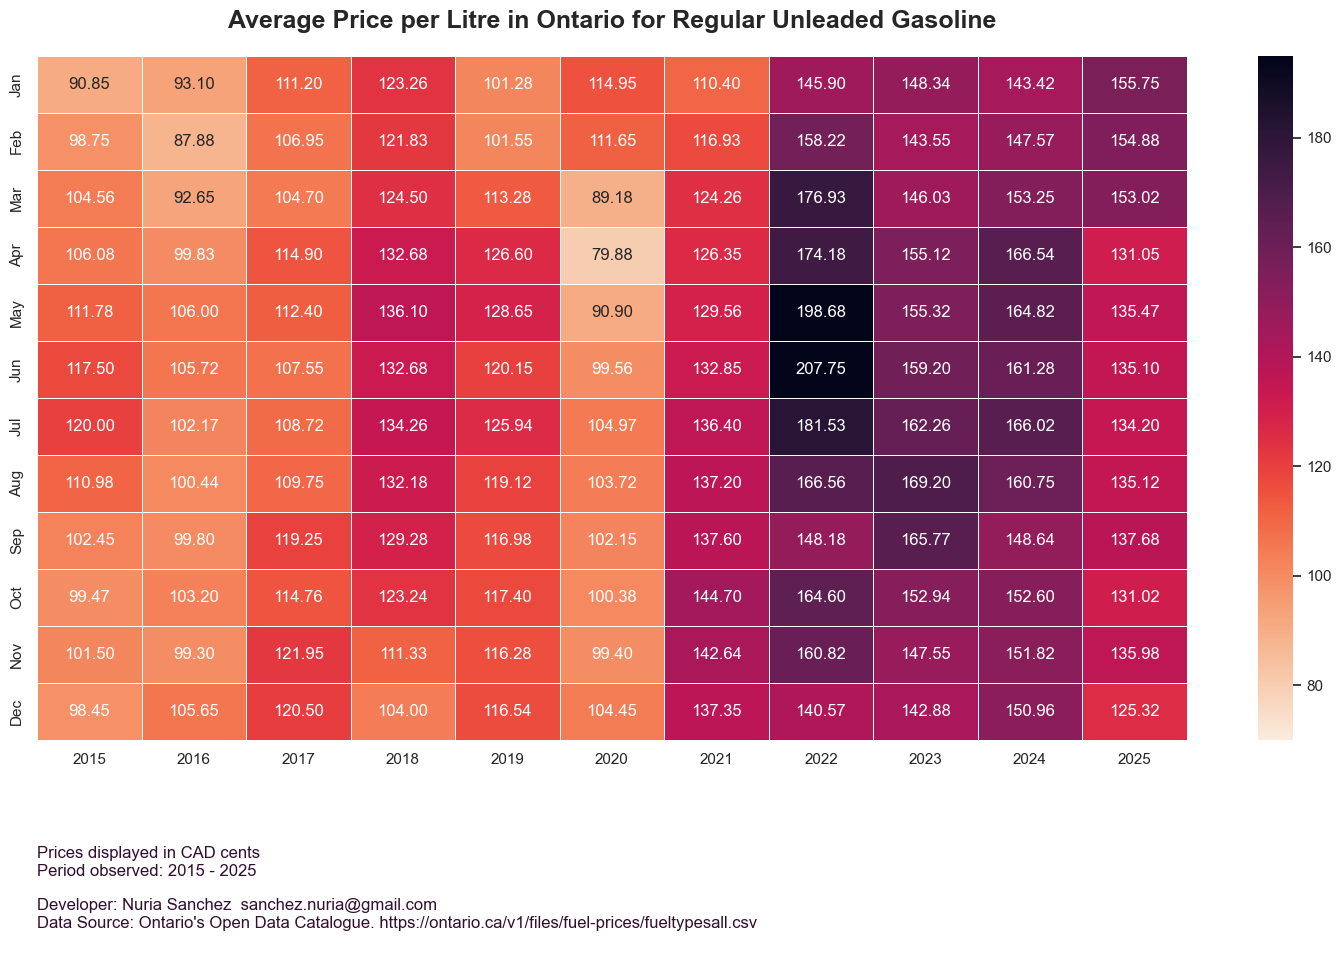

In [275]:
'''
Creation on HeatMap
Style :
Y axis : Months
X axis : Years
Values : Average Price per Litre in cents ($)
'''

sns.set_theme()

prices = (ontario_10y.pivot(index='month', columns='year', values= 'AvgPrice'))

fig, ax = plt.subplots(figsize = (15,10))

sns.heatmap(prices, annot = True, fmt= '.2f', linewidths= .5, ax = ax, cmap= 'rocket_r', vmin=70, vmax=195)

ax.set_title("Average Price per Litre in Ontario for Regular Unleaded Gasoline", fontsize=18, fontweight='bold', pad = 20)

note = f"""
Prices displayed in CAD cents
Period observed: {past_10_year} - {current_year-1}

Developer: Nuria Sanchez  sanchez.nuria@gmail.com
Data Source: Ontario's Open Data Catalogue. https://ontario.ca/v1/files/fuel-prices/fueltypesall.csv
"""

ax.annotate(note, xy=(0, -0.3), xycoords="axes fraction", fontsize=12, color="#330E30")
plt.xlabel(None)
plt.ylabel(None)
plt.tight_layout()

plt.savefig('visualization2.png')
plt.show()


## Average Price per Litre in Ontario for Regular Unleaded Gasoline.

The primary message of the visualization is to show how the average price of regular unleaded gasoline has fluctuated over the last decade in Ontario. Focusing only on the last 10 completed calendar years. Prices are shown in cents.

---
I created my data visualization using Python, specifically the Seaborn library, to produce a heatmap representing the average price of regular unleaded gasoline in Ontario for the last 10 completed calendar years. Seaborn was selected because it provides a clear and structured way to generate statistical visualizations while allowing full reproducibility through code. The heatmap format was chosen to emphasize variation and intensity in price changes across time.

The intended audience includes policymakers, economists, transportation planners, researchers, and Ontario residents who want to better understand recent fuel price trends. I specifically focused on regular motor gasoline because it is the most commonly used transportation fuel in Ontario, making it the most relevant indicator of everyday transportation costs for households and businesses. The visualization was therefore designed to be accessible to both technical and non-technical audiences, offering a clear and concise summary of recent price trends without overwhelming viewers with unnecessary detail.

The heatmap avoids partial or misleading comparisons and ensures that each year is fully represented. The color intensity in the heatmap allows viewers to quickly identify higher and lower price periods and observe patterns such as sustained increases, declines, or volatility across years.

Several design principles guided the creation of this visualization. First, I prioritized visual hierarchy and readability. I used a font size of 18 for the main title, and 12 for notes. This establishes a clear structure, helping viewers immediately identify the purpose of the chart and any relevant contextual information. Second, I selected a high-contrast color palette to enhance accessibility and clarity. The strong contrast between low and high values makes differences in gasoline prices visually distinct and easy to interpret. Because heatmaps rely heavily on color to convey magnitude, ensuring clear contrast was essential for both interpretability and accessibility.

Reproducibility was ensured by generating the visualization entirely through Python code. Anyone with access to the dataset and the script can recreate the exact same heatmap. Importantly, the time window was defined using dynamic year variables rather than hardcoding specific years such as 2015–2025. The script automatically identifies the most recent completed year and calculates the previous nine years relative to it. This approach ensures that when new yearly data becomes available, the visualization updates automatically without requiring manual code changes. This enhances transparency, credibility, and long-term maintainability. If a non-reproducible tool—such as manual design software—had been used, it would be more difficult to verify results, replicate the visualization, or update it consistently over time.

Accessibility was also a central consideration. The use of high-contrast colors improves readability for individuals with visual impairments. Clear labeling, legible font sizes, and a simple layout reduce cognitive load and make the visualization easier to interpret. By limiting the time frame to the last 10 completed years, the heatmap avoids overcrowding and maintains clarity. Additionally, consistent labeling and straightforward formatting support viewers who may not have a technical background.

The individuals and communities impacted by this visualization include Ontario drivers, households managing transportation costs, logistics and delivery companies, and policymakers evaluating economic or energy-related policies. Researchers analyzing inflation, consumer spending, or energy markets may also use this information. Since gasoline prices affect cost of living and economic stability, the visualization may contribute to broader public discussions about affordability and energy policy.

When selecting features from the dataset, I focused specifically on the variable representing the total average price of regular unleaded gasoline in Ontario and the calendar year. Other fuel types or additional economic indicators were excluded to maintain clarity and prevent the visualization from becoming cluttered. The goal was to present a focused, interpretable summary of recent gasoline price trends rather than a comprehensive energy market analysis.

Finally, significant “underwater labour” contributed to the final product. This includes cleaning and validating the dataset, ensuring that only completed calendar years were included, verifying that averages were correctly calculated, and confirming consistency in formatting. Additional unseen work involved selecting an appropriate color palette, adjusting scaling for visual balance, refining font sizes for readability, and testing the script to ensure the dynamic year variables function correctly. Although not visible in the final heatmap, this preparatory and iterative work was essential to producing a reliable, accurate, and accessible data visualization.
